<a href="https://colab.research.google.com/github/gkhamis04/George-Khamis/blob/main/Autism_Prediction_using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
from google.colab import files
import os

files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Done 🚀")

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Done 🚀


In [43]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("konikarani/autismdiagnosis")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'autismdiagnosis' dataset.
Path to dataset files: /kaggle/input/autismdiagnosis


In [44]:
import shutil
import os

shutil.copytree(path, "./autism_data", dirs_exist_ok=True)
print("Done! 🚀")

Done! 🚀


**Importing libraries**

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import RandomOverSampler
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import warnings
warnings.filterwarnings('ignore')

In [46]:
df = pd.read_csv("/content/autism_data/Autism_Prediction/train.csv")
df.head()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,...,f,?,no,no,Austria,no,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,...,m,?,no,no,India,no,2.255185,18 and more,Self,0
2,3,1,1,1,1,1,1,1,1,1,...,m,White-European,no,yes,United States,no,14.851484,18 and more,Self,1
3,4,0,0,0,0,0,0,0,0,0,...,f,?,no,no,United States,no,2.276617,18 and more,Self,0
4,5,0,0,0,0,0,0,0,0,0,...,m,?,no,no,South Africa,no,-4.777286,18 and more,Self,0


In [47]:
df.shape

(800, 22)

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               800 non-null    int64  
 1   A1_Score         800 non-null    int64  
 2   A2_Score         800 non-null    int64  
 3   A3_Score         800 non-null    int64  
 4   A4_Score         800 non-null    int64  
 5   A5_Score         800 non-null    int64  
 6   A6_Score         800 non-null    int64  
 7   A7_Score         800 non-null    int64  
 8   A8_Score         800 non-null    int64  
 9   A9_Score         800 non-null    int64  
 10  A10_Score        800 non-null    int64  
 11  age              800 non-null    float64
 12  gender           800 non-null    object 
 13  ethnicity        800 non-null    object 
 14  jaundice         800 non-null    object 
 15  austim           800 non-null    object 
 16  contry_of_res    800 non-null    object 
 17  used_app_before 

In [49]:
df.columns

Index(['ID', 'A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score',
       'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age',
       'gender', 'ethnicity', 'jaundice', 'austim', 'contry_of_res',
       'used_app_before', 'result', 'age_desc', 'relation', 'Class/ASD'],
      dtype='object')

In [50]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,800.0,400.500000,231.084400,1.000000,200.750000,400.500000,600.250000,800.000000
A1_Score,800.0,0.560000,0.496697,0.000000,0.000000,1.000000,1.000000,1.000000
A2_Score,800.0,0.530000,0.499411,0.000000,0.000000,1.000000,1.000000,1.000000
A3_Score,800.0,0.450000,0.497805,0.000000,0.000000,0.000000,1.000000,1.000000
A4_Score,800.0,0.415000,0.493030,0.000000,0.000000,0.000000,1.000000,1.000000
A5_Score,800.0,0.395000,0.489157,0.000000,0.000000,0.000000,1.000000,1.000000
A6_Score,800.0,0.303750,0.460164,0.000000,0.000000,0.000000,1.000000,1.000000
A7_Score,800.0,0.397500,0.489687,0.000000,0.000000,0.000000,1.000000,1.000000
A8_Score,800.0,0.508750,0.500236,0.000000,0.000000,1.000000,1.000000,1.000000
A9_Score,800.0,0.495000,0.500288,0.000000,0.000000,0.000000,1.000000,1.000000


*Data Cleaning*

In [51]:
df['ethnicity'].value_counts()

,count
ethnicity,
White-European,257
?,203
Middle Eastern,97
Asian,67
Black,47
South Asian,34
Pasifika,32
Others,29
Latino,17


In [52]:
df['relation'].value_counts()

,count
relation,
Self,709
?,40
Parent,29
Relative,18
Others,2
Health care professional,2


In [53]:
df = df.replace({'yes':1, 'no':0, '?':'Others', 'others':"Others"})

**Exploratory Data Analysis**

In [54]:
df['Class/ASD'].value_counts()

,count
Class/ASD,
0,639
1,161


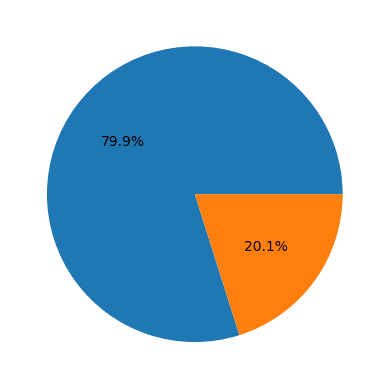

In [55]:
plt.pie(df['Class/ASD'].value_counts().values, autopct='%1.1f%%')
plt.show()

In [56]:
ints = []
objects = []
floats =[]

for col in df.columns :
  if df[col].dtype == 'int':
    ints.append(col)
  elif df[col].dtype == 'object':
    objects.append(col)
  elif df[col].dtype == 'float':
    floats.append(col)

In [57]:
ints.remove('ID')
ints.remove('Class/ASD')

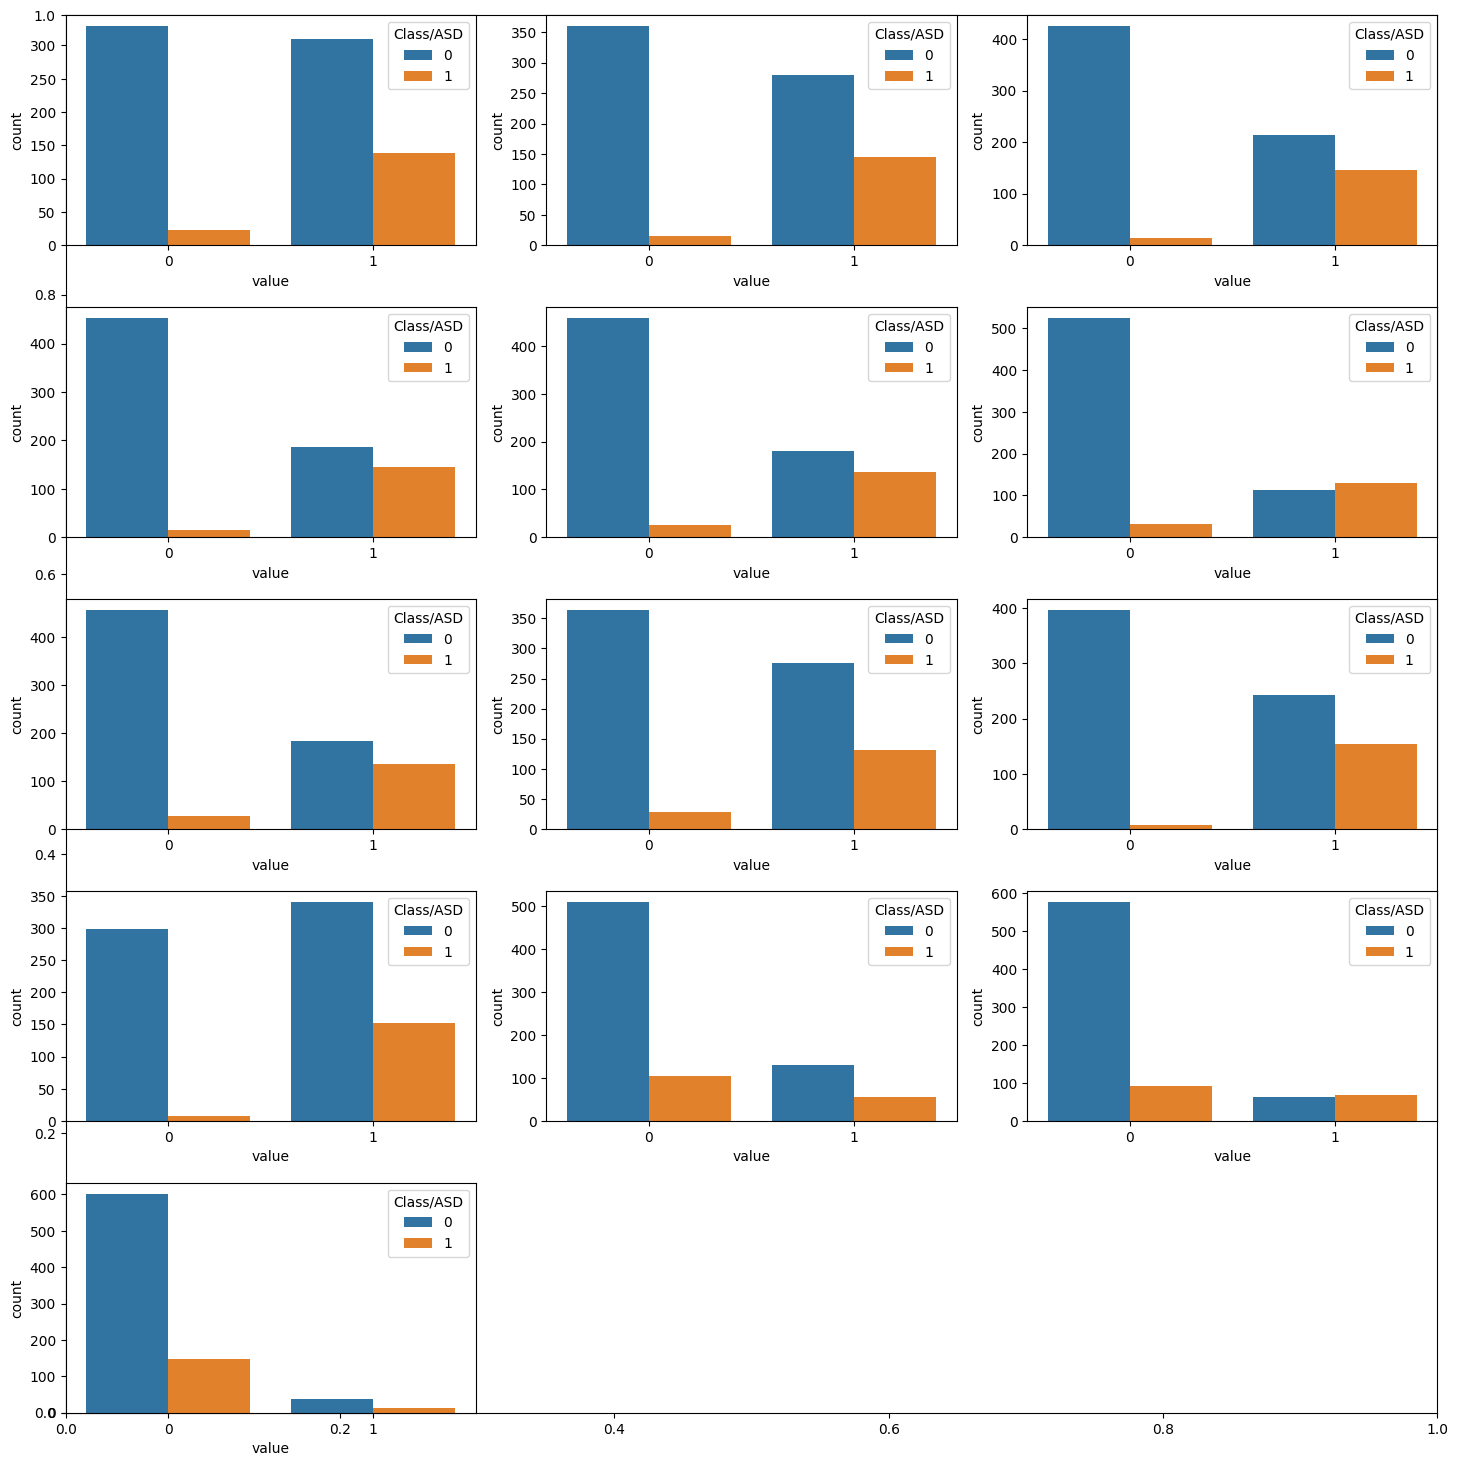

In [58]:
df_melted = df.melt(id_vars=['ID', 'Class/ASD'], value_vars=ints, var_name='col', value_name='value')

plt.subplots(figsize=(15,15))

for i, col in enumerate(ints):
  plt.subplot(5,3,i+1)

  sb.countplot(x='value', hue='Class/ASD', data=df_melted[df_melted['col'] == col])

plt.tight_layout()
plt.show()

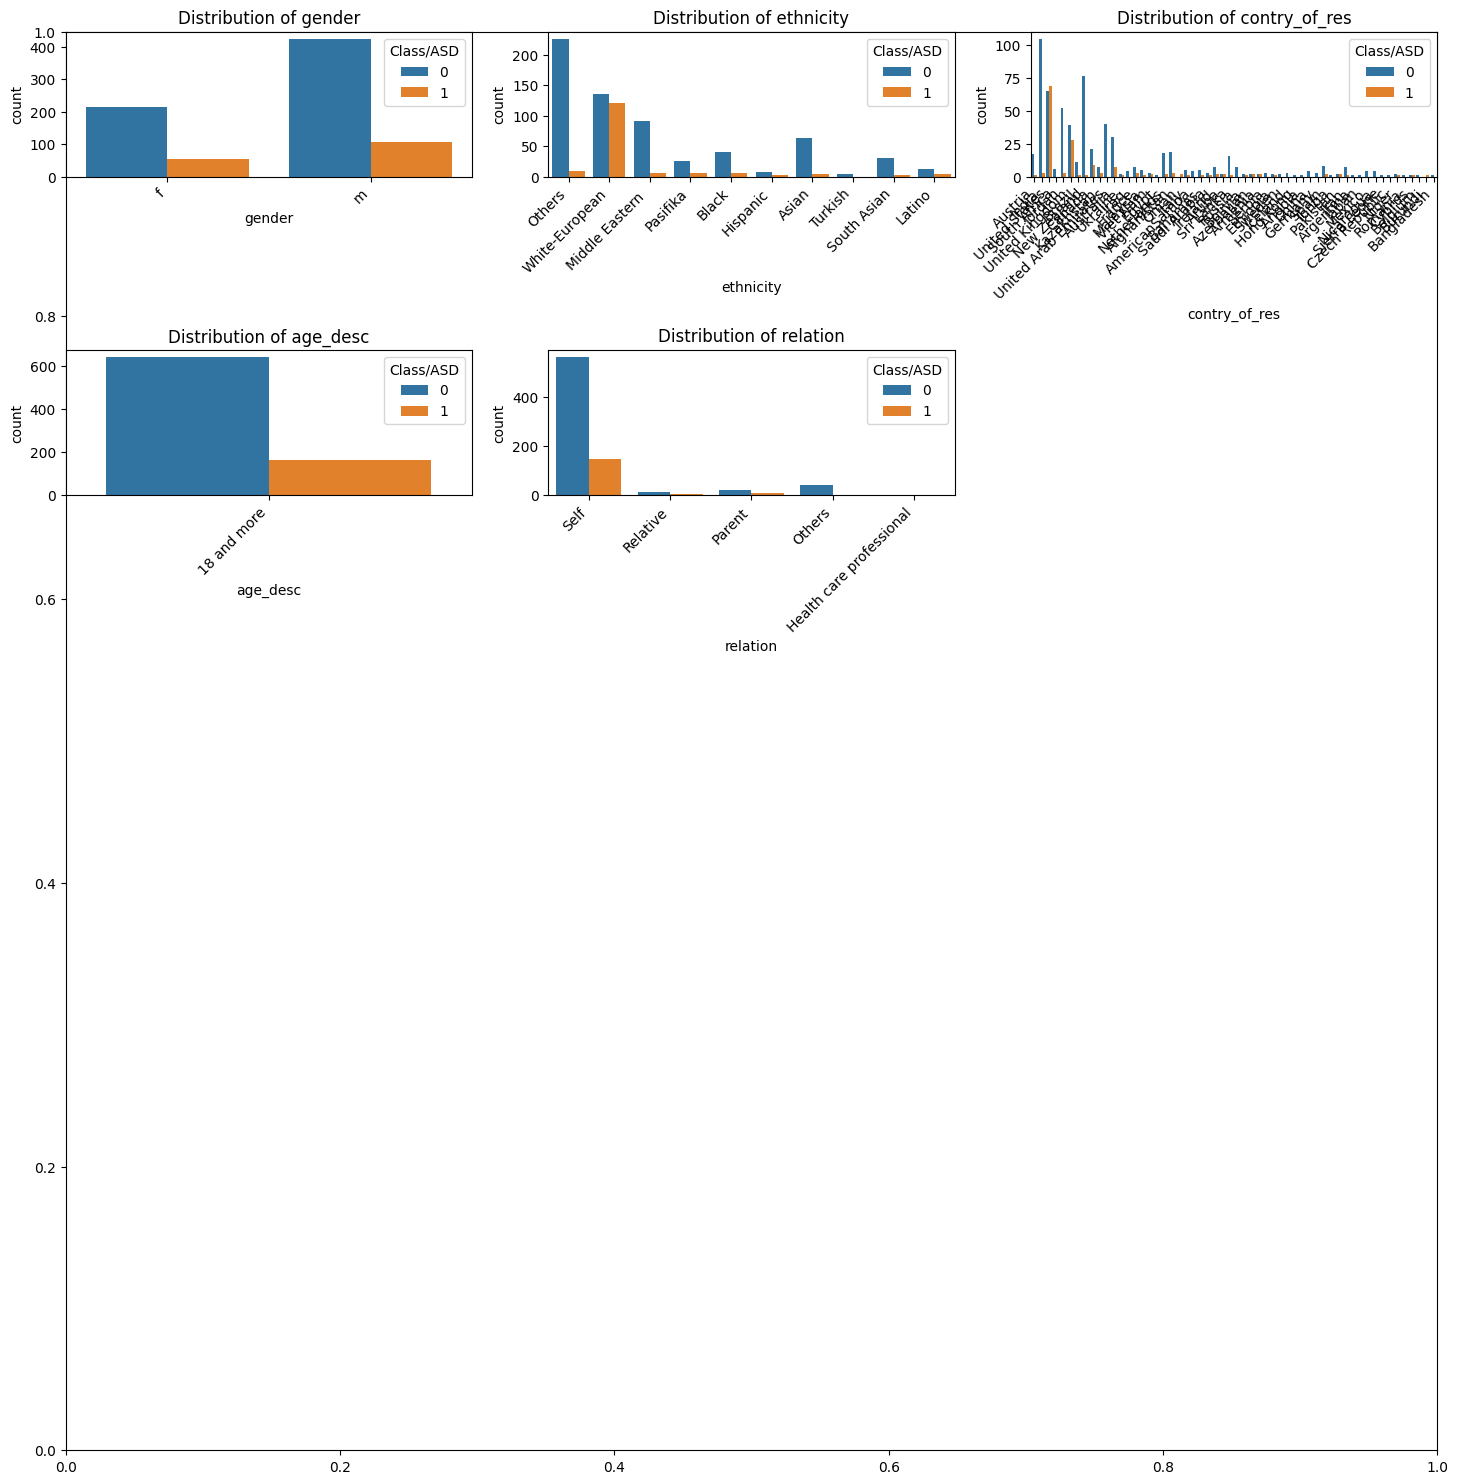

In [59]:
plt.subplots(figsize=(15, 15))

for i, col in enumerate(objects):
    plt.subplot(5, 3, i + 1)
    sb.countplot(x=col, hue='Class/ASD', data=df)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

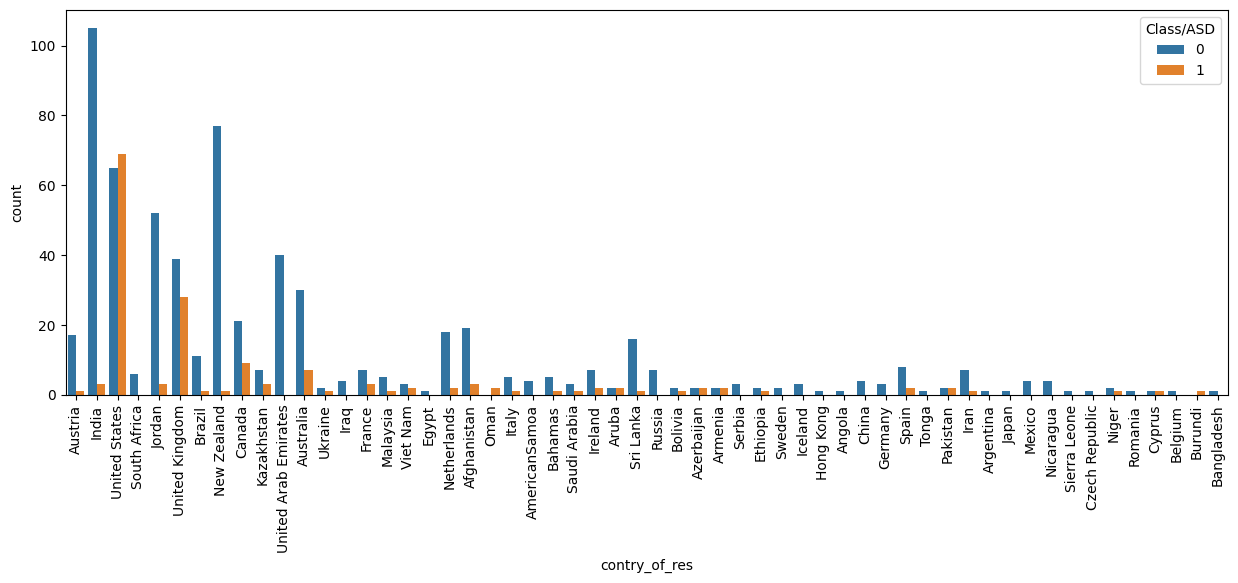

In [60]:
plt.figure(figsize=(15,5))
sb.countplot(data=df, x='contry_of_res', hue='Class/ASD')
plt.xticks(rotation=90)
plt.show()

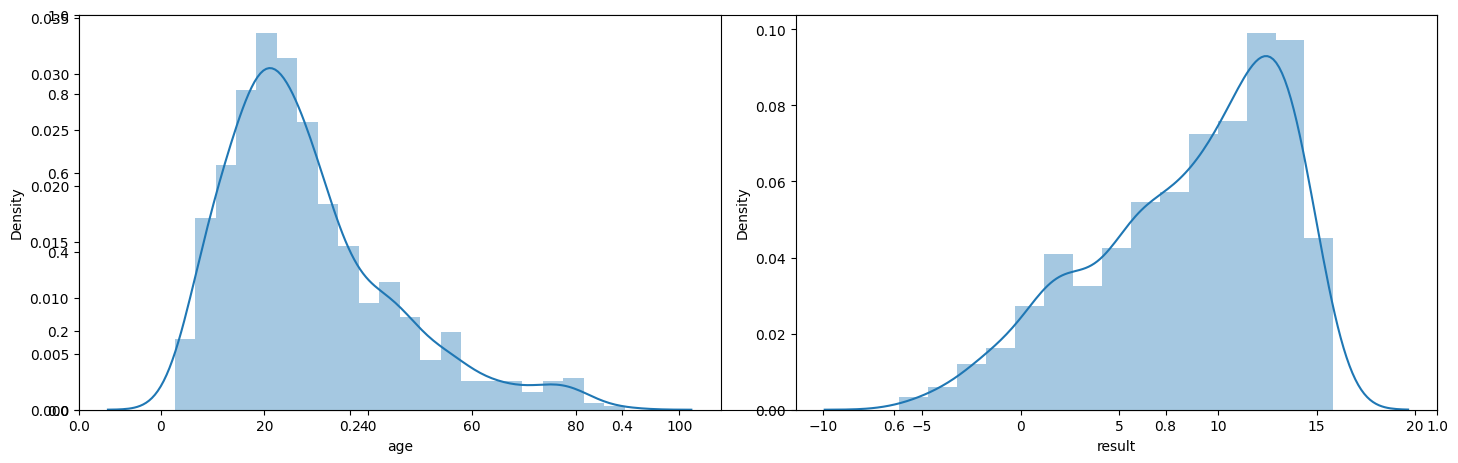

In [61]:
plt.subplots(figsize=(15,5))

for i, col in enumerate(floats):
  plt.subplot(1,2,i+1)
  sb.distplot(df[col])
plt.tight_layout()
plt.show()

In [62]:
df = df[df['result']>-5]
df.shape

(798, 22)

**Feature Engineering**

In [63]:
condetions = [
    df['age'] < 4,
    df['age'] < 12,
    df['age'] <18,
    df['age'] <40
]
choices = ['Toddler', 'Kid', 'Teenager', 'Young']

df['ageGroup'] = np.select(conditions, choices, default='Senior')

In [64]:
# بديل أسرع وأبسط لحساب sum_score
df['sum_score'] = df.loc[:, 'A1_Score':'A10_Score'].sum(axis=1)

In [65]:
df.head()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD,ageGroup,sum_score
0,1,1,0,1,0,1,0,1,0,1,...,0,0,Austria,0,6.351166,18 and more,Self,0,Young,6
1,2,0,0,0,0,0,0,0,0,0,...,0,0,India,0,2.255185,18 and more,Self,0,Senior,0
2,3,1,1,1,1,1,1,1,1,1,...,0,1,United States,0,14.851484,18 and more,Self,1,Kid,10
3,4,0,0,0,0,0,0,0,0,0,...,0,0,United States,0,2.276617,18 and more,Self,0,Young,0
4,5,0,0,0,0,0,0,0,0,0,...,0,0,South Africa,0,-4.777286,18 and more,Self,0,Senior,0


In [66]:
df['ind'] = df['austim'] + df['used_app_before'] + df['jaundice']

In [67]:
df.head()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD,ageGroup,sum_score,ind
0,1,1,0,1,0,1,0,1,0,1,...,0,Austria,0,6.351166,18 and more,Self,0,Young,6,0
1,2,0,0,0,0,0,0,0,0,0,...,0,India,0,2.255185,18 and more,Self,0,Senior,0,0
2,3,1,1,1,1,1,1,1,1,1,...,1,United States,0,14.851484,18 and more,Self,1,Kid,10,1
3,4,0,0,0,0,0,0,0,0,0,...,0,United States,0,2.276617,18 and more,Self,0,Young,0,0
4,5,0,0,0,0,0,0,0,0,0,...,0,South Africa,0,-4.777286,18 and more,Self,0,Senior,0,0


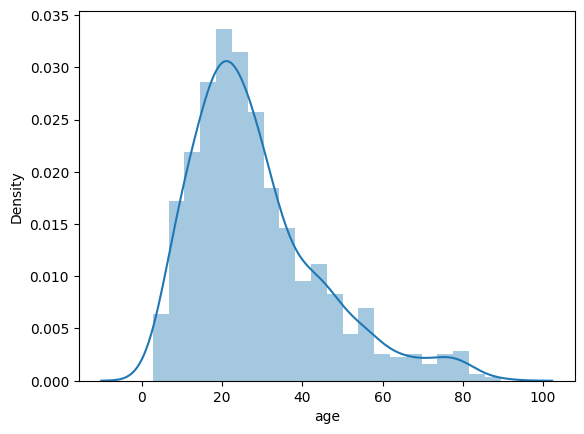

In [68]:
sb.distplot(df['age'])
plt.show()

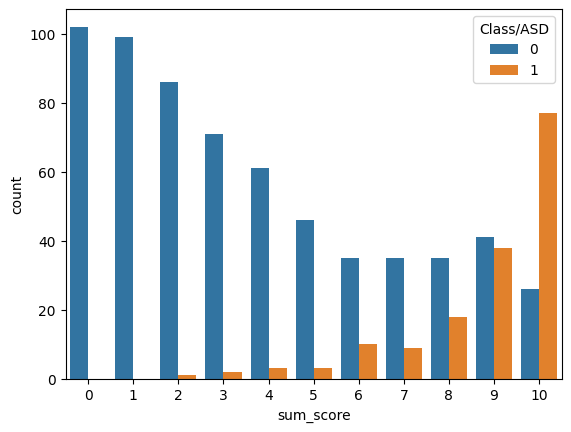

In [69]:
sns.countplot(x=df['sum_score'], hue=df['Class/ASD'])
plt.show()

In [70]:
df['age'] = np.log1p(df['age'])

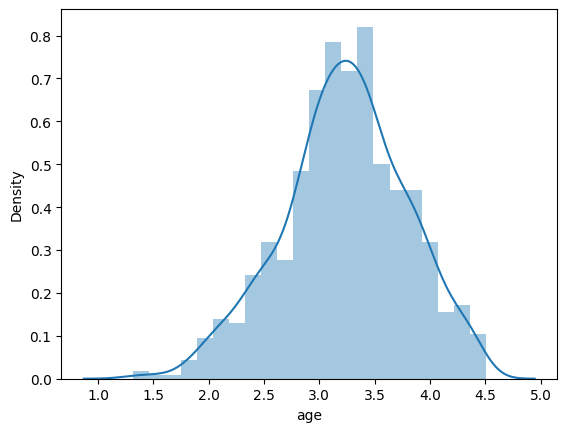

In [71]:
sb.distplot(df['age'])
plt.show()

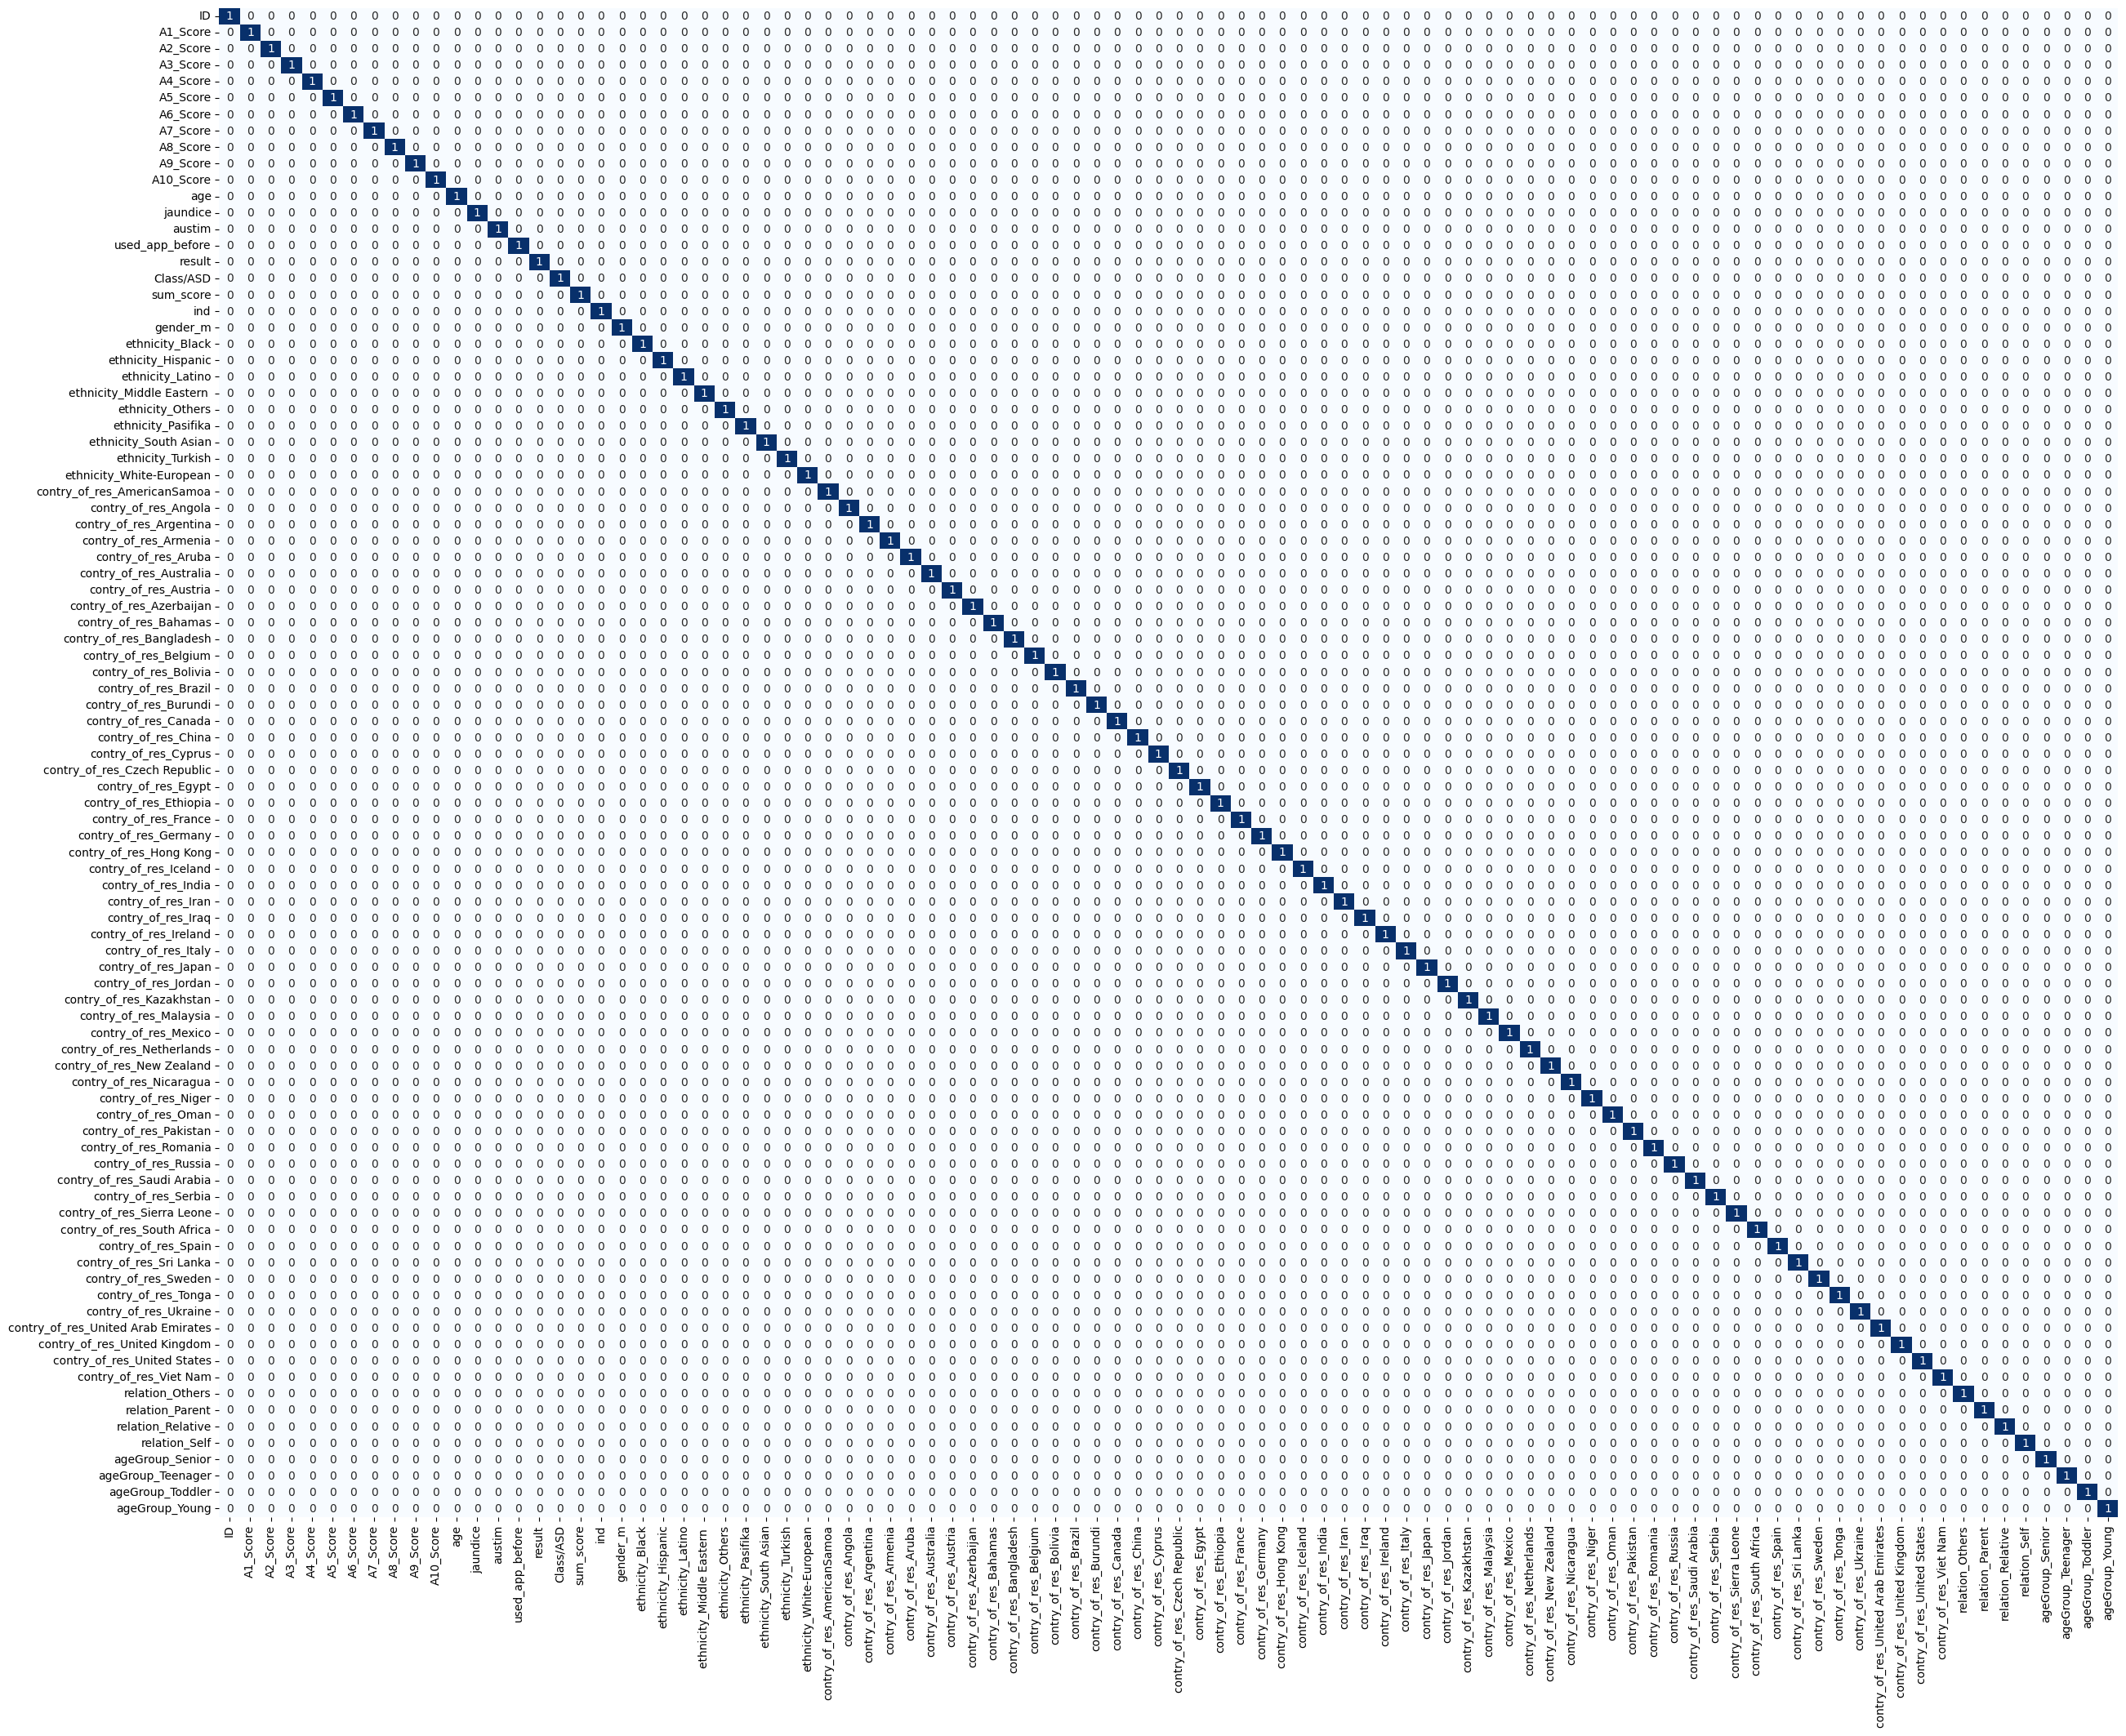

In [73]:
df = pd.get_dummies(df, drop_first=True)

plt.figure(figsize=(30, 24))
sns.heatmap(df.corr().abs() > 0.8, annot=True, cbar=False, cmap='Blues')
plt.show()

In [78]:
removal = ['ID', 'age_desc', 'used_app_before', 'austim', 'Class/ASD']

features = df.drop(columns=removal, errors='ignore')
target = df['Class/ASD']

In [80]:
X_train, X_val, Y_train, Y_val = train_test_split(
    features, target, test_size=0.2, random_state=10, stratify=target
)

ros = RandomOverSampler(sampling_strategy='minority', random_state=0)
X_train, Y_train = ros.fit_resample(X_train, Y_train)

print(X_train_res.shape, Y_train_res.shape)
print(X_val.shape, Y_val.shape)

(1018, 88) (1018,)
(160, 88) (160,)


In [81]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [82]:
models = [
    LogisticRegression(),
    XGBClassifier(eval_metric='logloss'),
    SVC(kernel='rbf', probability=True)
]

for model in models:
    model.fit(X_train, Y_train)

    print(f'{model.__class__.__name__} : ')
    print('Training ROC-AUC : ', metrics.roc_auc_score(Y_train, model.predict(X_train)))
    print('Validation ROC-AUC : ', metrics.roc_auc_score(Y_val, model.predict(X_val)))
    print('-' * 40)

LogisticRegression : 
Training ROC-AUC :  0.8163674022631394
Validation ROC-AUC :  0.8046875
----------------------------------------
XGBClassifier : 
Training ROC-AUC :  1.0
Validation ROC-AUC :  0.75
----------------------------------------
SVC : 
Training ROC-AUC :  0.8181188224364538
Validation ROC-AUC :  0.828125
----------------------------------------


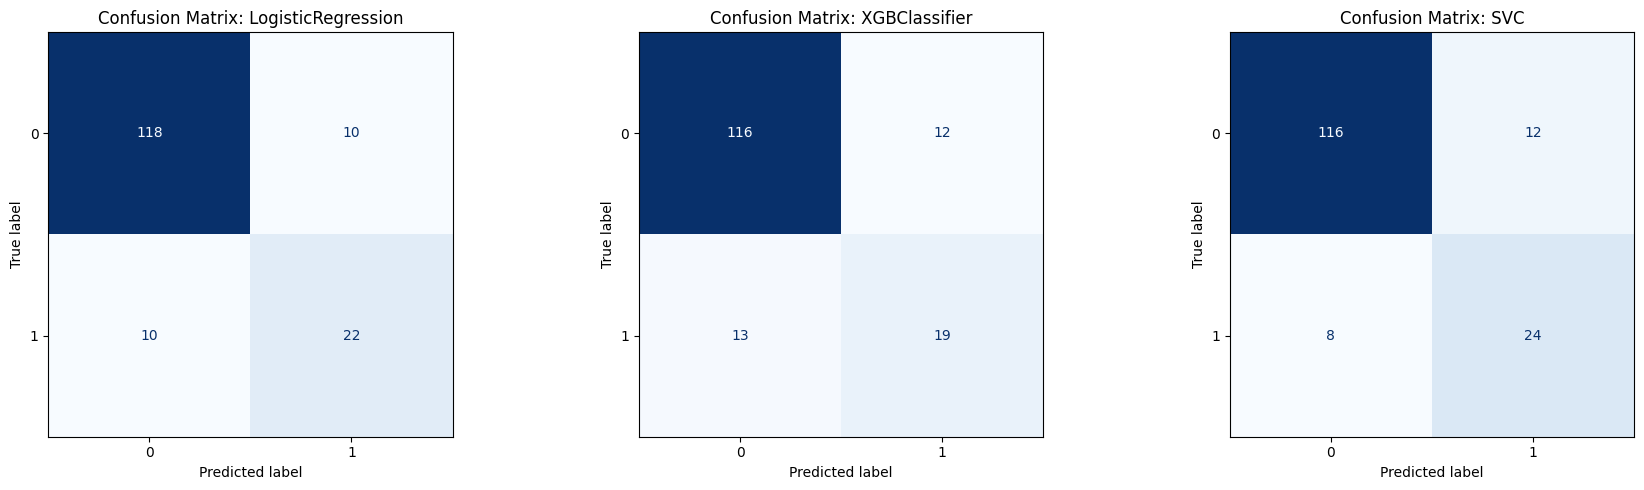

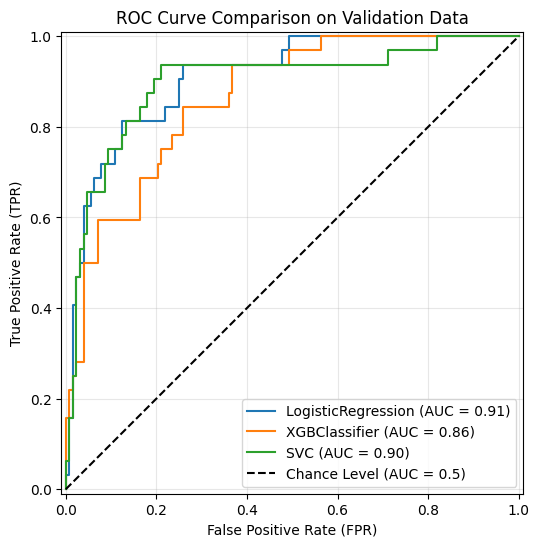

In [84]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, model in zip(axes, models):
    model_name = model.__class__.__name__

    ConfusionMatrixDisplay.from_estimator(
        model,
        X_val,
        Y_val,
        ax=ax,
        cmap='Blues',
        colorbar=False
    )
    ax.set_title(f'Confusion Matrix: {model_name}')

plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))

for model in models:
    model_name = model.__class__.__name__

    RocCurveDisplay.from_estimator(
        model,
        X_val,
        Y_val,
        name=model_name,
        ax=plt.gca()
    )

plt.plot([0, 1], [0, 1], 'k--', label='Chance Level (AUC = 0.5)')

plt.title('ROC Curve Comparison on Validation Data')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()